# Generate bound curves for all datasets and MMLS

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from pathlib import Path
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from microscope.datasets import custom_dsprites
from microscope.datasets.generic_dataset_loader import DatasetName, load_dataset
from microscope.computations_grid.data_analysis.data_analysis import (
    compute_measures_multiclass,
    plot_pairs_multiclass,
    plot_3d_pca_projections_multiclass,
    clip_results_multiclass,
    MeasureAggregates
)

## Load the measures for all datasets

In [2]:
normalize_for_volume = True
number_of_dims = 4
output_dir = Path(f"~/experiments/manifold_microscope/manifold_fitting/measures_all_datasets/dsprites_measures_vol_norm_{normalize_for_volume}").expanduser() 

output_path = output_dir / f"dsprites_{number_of_dims}.pkl"
with open(output_path, "rb") as f:
    measures_dsprites = clip_results_multiclass(pickle.load(f))

In [3]:
normalize_for_volume = True
number_of_dims = 3
output_dir = Path(f"~/experiments/manifold_microscope/manifold_fitting/measures_all_datasets/coil20_vol_norm_{normalize_for_volume}") .expanduser()

output_path = output_dir / f"coil20_{number_of_dims}.pkl"
with open(output_path, "rb") as f:
    measures_coil20 = clip_results_multiclass(pickle.load(f))

In [ ]:
with open(Path("~/experiments/manifold_microscope/toy_datasets_fitting_medium_mmls_till_5000_all_distances/distance_and_measure_results.pkl").expanduser(), "rb") as f:
    toy_dataset_results = pickle.load(f)

## Generate the curves

In [5]:
results_df = []

for path in Path("~/experiments/manifold_microscope/manifold_fitting/training_absolute_ratio_dl_models_fixed_test_set_mmls_FINAL").expanduser().glob("**/*.pkl"):
    dataset, method, data_perc, dims, noise, n_iter = path.parent.name.split("__")
    
    with open(path, "rb") as f:
        results = pickle.load(f)

    results_df.append(dict(
        dataset=dataset,
        method=method,
        data_perc=float(data_perc), 
        dims=int(dims), 
        noise=float(noise), 
        n_iter=int(n_iter),
        number_of_train_points=results["number_of_train_points"],
        number_of_test_points=results["number_of_test_points"],
        hausdorff_distance=results["hausdorff_distance"],
        avg_distance=results["pointwise_distances"].mean()
    ))

results_df = pd.DataFrame(results_df)

In [6]:
results_df.shape

(212, 10)

In [7]:
results_df.head()

,dataset,method,data_perc,dims,noise,n_iter,number_of_train_points,number_of_test_points,hausdorff_distance,avg_distance
0,extended_coil20,MMLS,0.4,1,0.0,1,100,108,12.085001,7.251779
1,custom_dsprites_balanced,MMLS,0.2,2,0.0,2,107,230,4.242675,1.630946
2,custom_dsprites_balanced,MMLS,0.3,1,0.0,1,10,14,7.286685,4.055747
3,extended_coil20,MMLS,0.6,2,0.0,1,3156,500,10.190563,6.316925
4,custom_dsprites_balanced,MMLS,0.7,4,0.0,1,137275,500,2.815711,0.694557


## Polish and export bounds

In [11]:
def robust_lower_bound(f_values, g, x, q=0.01):
    lower_bound = g(x)
    return np.quantile(f_values / lower_bound, q=q)

def robust_upper_bound(f_values, g, x, q=0.99):
    upper_bound = g(x)
    return np.quantile(f_values / upper_bound, q=q)

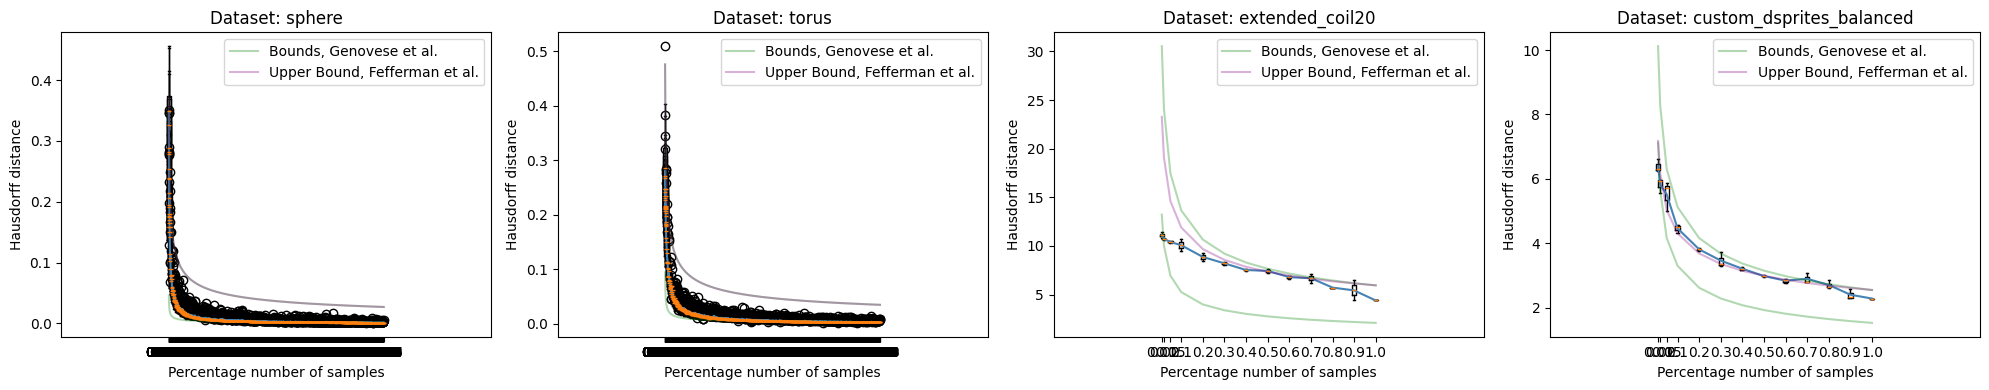

In [12]:
def g_lower_genovese(x): 
    return (1/x)**(2/(2 + d))
def g_upper_genovese(x): 
    return (np.log(x)/x)**(2/(2 + d))

def g_upper_fefferman(x): 
    return (np.log(x) / x)**(1 / d)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

curves_to_export = {}

for i, dataset_name in enumerate(["sphere", "torus", "extended_coil20", "custom_dsprites_balanced"]):
    match dataset_name:
        case "custom_dsprites_balanced":
            d = 4
            dataset_results = (
                results_df
                [(results_df["dataset"] == dataset_name) & (results_df["dims"] == d)]
                .groupby("number_of_train_points")
                .agg(list)
            )
            tau = np.min(list(measures_dsprites.measure_aggregates.normalized_min_reaches.values()))
        case "extended_coil20":
            d = 3
            dataset_results = (
                results_df
                [(results_df["dataset"] == dataset_name) & (results_df["dims"] == d)]
                .groupby("number_of_train_points")
                .agg(list)
            )
            tau = np.min(list(measures_coil20.measure_aggregates.normalized_min_reaches.values()))
        case "sphere" | "torus":
            d = 2
            outputs_of_dataset = toy_dataset_results[dataset_name.title()]
            dataset_results = (
                pd.DataFrame(
                    map(lambda x: (x[0], list(x[1])), outputs_of_dataset["hausdorff_distances"].items()), 
                    columns=["number_of_train_points", "hausdorff_distance"]
                )
                .assign(data_perc=lambda df: (df["number_of_train_points"] / df["number_of_train_points"].max()).map(lambda x: [x]))
                .set_index("number_of_train_points")
            )
            tau = outputs_of_dataset["measures"].min_reach
            
    name = f"{dataset_name}, dims: {d}"
    
    haus_all = dataset_results["hausdorff_distance"]
    
    f_values_haus = np.array(haus_all.map(np.mean))
    x = np.array(dataset_results.index)

    x_perc = np.array(dataset_results["data_perc"].str[0])

    x_log = np.log(x).reshape(-1, 1)
    y_log = np.log(f_values_haus)
    
    # linear regression
    reg = LinearRegression().fit(x_log, y_log)
    alpha_fit = -reg.coef_[0]
    C_fit = np.exp(reg.intercept_)
    f_vals_fitted = C_fit * x**(-alpha_fit)
    
    C1 = robust_lower_bound(f_vals_fitted, g_lower_genovese, x)
    C2 = robust_upper_bound(f_vals_fitted, g_upper_genovese, x)
    C = robust_upper_bound(f_vals_fitted, g_upper_fefferman, x)
    
    yl = C1 * g_lower_genovese(x)
    yu = C2 * g_upper_genovese(x)
    yu_f = C * g_upper_fefferman(x)

    curves_to_export[dataset_name] = {
        "x": x, 
        "empirical": f_values_haus, 
        "empirical_all_repetitions": haus_all, 
        "lower_genovese": yl, 
        "upper_genovese": yu, 
        "upper_fefferman": yu_f
    }
    
    ax = axes[i]
    # ax.set_title(f"C1: {C1:.2f}, C2: {C2:.2f}, C: {C:.2f}")
    ax.set_title(f"Dataset: {dataset_name}")
    ax.boxplot(haus_all, positions=x_perc, widths=0.02)
    ax.plot(x_perc, f_values_haus, color="steelblue")
    # ax[1].plot(x, f_vals_fitted, color="steelblue")
    ax.plot(x_perc, yl, color="green", alpha=0.3, label="Bounds, Genovese et al.")
    ax.plot(x_perc, yu, color="green", alpha=0.3)
    ax.plot(x_perc, yu_f, color="purple", alpha=0.3, label="Upper Bound, Fefferman et al.")
    # ax[1].set_ylim((0, 1.05*f_values_haus.max()))
    ax.set_xlabel("Percentage number of samples")
    ax.set_ylabel("Hausdorff distance")
    ax.legend()

np.savez("all_datasets_bounds.npz", **curves_to_export)

plt.tight_layout()
plt.savefig("all_datasets_bounds.png", dpi=200)
plt.show()